# Assignment 3: Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection (HW3)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import os
import re
import warnings
import plotly.express as px
import requests

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

## Part 1: Dataset Selection and Overview

This section introduces the dataset used for the analysis, detailing its source, purpose, and key characteristics. It ensures a foundational understanding of the data before proceeding with cleaning and modeling.

### 1.1 Dataset Overview

**Source:** The data was downloaded from the Kaggle platform.

**Dataset Name:** 'Cars Datasets 2025' (Kaggle ID: `abdulmalik1518/cars-datasets-2025`).

**Purpose:** Intended to facilitate project building and market research in the automotive industry, covering aspects such as acceleration performance, speed, horsepower, market prices (in USD), and propulsion types (petrol, hybrid, electric, diesel).

**Requirements Met:** The dataset meets the assignment's requirements – it is tabular, contains over 1000 rows, more than 10 columns (companies, models, price, fuel type, seats, etc.), and includes both numerical and categorical variables.

**Preparation steps performed in this section (as a direct continuation of HW1 and HW2):**
1. Data download via Kaggle API.
2. String cleaning and conversion of columns to numerical values (Horsepower, Speed, Price, Acceleration, Torque).
3. Division into engine categories and data completion based on group median.
4. Handling of specific anomalies.
5. Standardization (Scaling) is mandatory for all numerical features in preparation for distance-based models.

##1.1 Dataset Overview for Data Analysts
This section provides essential details about the 'Cars Datasets 2025' dataset, crucial for any data analyst working with this file.

###1. Dataset Name: Cars Datasets 2025

###2. Source: Kaggle Platform

Kaggle Dataset ID: abdulmalik1518/cars-datasets-2025
Direct URL: https://www.kaggle.com/datasets/abdulmalik1518/cars-datasets-2025
Uploader: abdulmalik1518
License: Apache-2.0
###3. Date Accessed: This dataset was downloaded and integrated into the notebook for analysis on [Insert Current Date/Approximate Access Date if known, e.g., April 2026 based on Kaggle logs].

###4. Purpose of Collection: This dataset was collected to facilitate project building and market research within the automotive industry. It provides detailed information on various car models for the year 2025, enabling analysis of market trends, performance benchmarks, and competitive landscapes.

###5. Key Data Characteristics:

Structure: Tabular data.
Size: Contains an initial 1218 entries (rows) and 11 columns, with cleaned data resulting in 1213 entries and additional derived columns.
Variables: The dataset includes a mix of numerical and categorical variables:
Numerical (Cleaned): HorsePower_cleaned, Total Speed_cleaned, Cars Prices_cleaned, Torque_cleaned, CC_Capacity_cleaned, Battery_Capacity_cleaned, Performance_cleaned.
Categorical: Company Names, Cars Names, Fuel Types, Seats, Engine_Category.
Content Focus: Covers aspects such as acceleration performance, top speed, horsepower, market prices (in USD), and propulsion types (petrol, hybrid, electric, diesel).
6. Data Granularity: Each row typically represents a specific car model with its detailed specifications.

> KAGGLE

In [3]:
# Install the Kaggle library
!pip install kaggle

In [4]:
# Upload the Kaggle API key to your notebook
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle (1).json


In [5]:
# Place the API key where the Kaggle library can recognize it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download abdulmalik1518/cars-datasets-2025
!unzip cars-datasets-2025.zip

Dataset URL: https://www.kaggle.com/datasets/abdulmalik1518/cars-datasets-2025
License(s): apache-2.0
cars-datasets-2025.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  cars-datasets-2025.zip
replace Cars Datasets 2025.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: Cars Datasets 2025.csv  


In [9]:
data = pd.read_csv('./Cars Datasets 2025.csv', encoding='latin1')
df = data.copy()

## Part 2: Initial Data Inspection and Cleansing

Our first step is to gain a foundational understanding of the dataset's structure and contents. This involves inspecting the data types, identifying missing values, and detecting any duplicate entries. Addressing these basic issues early ensures that our subsequent analysis is based on a robust and reliable dataset. We want to quickly see the general health of our data.

In [10]:
# Display basic information about the DataFrame, including data types and non-null counts.
df.info()

# Check for and remove duplicate rows to ensure each entry is unique.
print(f"\nNumber of duplicate rows in df before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows in df after removal: {df.duplicated().sum()}")

# Display a summary of missing values for all columns, showing count and percentage.
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing_data, 'Percent (%)': missing_percent})
print("\n--- Missing Values Initial Check ---")
display(missing_df[missing_df['Missing'] > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1218 non-null   object
 1   Cars Names                 1218 non-null   object
 2   Engines                    1218 non-null   object
 3   CC/Battery Capacity        1215 non-null   object
 4   HorsePower                 1218 non-null   object
 5   Total Speed                1218 non-null   object
 6   Performance(0 - 100 )KM/H  1212 non-null   object
 7   Cars Prices                1218 non-null   object
 8   Fuel Types                 1218 non-null   object
 9   Seats                      1218 non-null   object
 10  Torque                     1217 non-null   object
dtypes: object(11)
memory usage: 104.8+ KB

Number of duplicate rows in df before removal: 4
Number of duplicate rows in df after removal: 0

--- Missing Values Initial Check ---

,Missing,Percent (%)
CC/Battery Capacity,3,0.247117
Performance(0 - 100 )KM/H,6,0.494234
Torque,1,0.082372


### 2.1 Cardinality Check and Unique Value Analysis

Beyond duplicates, understanding the cardinality of each column—the number of unique values it contains—is crucial. Low cardinality columns (especially those with just one unique value) might be constant and thus uninformative for analysis, or indicate potential issues if they should have more variance. High cardinality columns (many unique values) can point to identifier-like features or require specific handling for categorical analysis.

In [15]:
try:
    # Attempt to use existing df if it's already defined
    df.head()
except NameError:
    # If df is not defined, first check if the file exists
    file_path = './Cars Datasets 2025.csv'
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}. Attempting to re-download and unzip.")
        # Re-run Kaggle download and unzip commands. This assumes Kaggle API is already configured.
        # Adding -q for quiet output and -o for overwrite (if zip exists) for unzip.
        !kaggle datasets download abdulmalik1518/cars-datasets-2025 -q
        !unzip -o cars-datasets-2025.zip -d .
        # Remove the zip file after extraction to keep the directory clean
        if os.path.exists('cars-datasets-2025.zip'):
            os.remove('cars-datasets-2025.zip')

    # Now try to load the data from the (now hopefully present) file
    data = pd.read_csv(file_path, encoding='latin1')
    df = data

# Check cardinality for all columns in the current DataFrame.
print("--- Cardinality of each column in df ---")
cardinality_df = pd.DataFrame({'Column': df.columns, 'Unique Values': df.nunique().values})
display(cardinality_df.sort_values(by='Unique Values', ascending=False))

# Identify columns with very low cardinality (e.g., only one unique value).
single_value_cols = cardinality_df[cardinality_df['Unique Values'] == 1]['Column'].tolist()

if single_value_cols:
    print(f"\n--- Columns with only one unique value (potentially uninformative): {single_value_cols} ---\n")
    for col in single_value_cols:
        print(f"Column '{col}': Unique value is '{df[col].iloc[0]}'")
else:
    print("\nNo columns found with only one unique value.")

--- Cardinality of each column in df ---


,Column,Unique Values
1,Cars Names,1200
7,Cars Prices,534
4,HorsePower,455
13,Cars Prices_cleaned,451
2,Engines,355
11,HorsePower_cleaned,316
3,CC/Battery Capacity,311
10,Torque,263
17,Engine_Battery_Description,247
14,Torque_cleaned,230



No columns found with only one unique value.


### 2.2 Handling Specific Missing Values in 'Torque'

Upon initial inspection, we observed that the 'Torque' column contains a few missing values. Specifically, one entry for a Mazda concept car has a missing 'Torque' value, which makes sense as it's a concept and may not have finalized specifications. Given the small number of missing values and the nature of this particular entry, we've decided to remove this row. This approach ensures data integrity without significantly impacting the overall dataset size.

In [16]:
# Removing rows with NaN values in 'Torque' column as it's a critical performance metric and imputation might not be accurate for a concept car.
df = df.dropna(subset=['Torque']).copy()

## Part 3: Data Cleaning, Transformation, and Feature Engineering

In this section, we focus on transforming raw data into a clean, usable format and creating new features that can enhance our analysis. Many columns currently contain text alongside numerical values or are in formats unsuitable for quantitative analysis. Our goal is to extract clean numerical data, standardize units, and derive meaningful new categorical and descriptive features. This will enable us to perform accurate statistical analysis and build insightful visualizations.

### 3.1 Initial Data Cleaning and Feature Extraction

This step involves cleaning various columns by extracting numerical components, removing extraneous text (e.g., '$', 'cc', 'hp', commas), and converting them to appropriate numerical data types (integers or floats). Specifically, we process `HorsePower`, `Total Speed`, `Cars Prices`, `Torque`, and `Performance(0 - 100 )KM/H`. We also separate `CC/Battery Capacity` into `CC_Capacity_cleaned` and `Battery_Capacity_cleaned` to handle combustion engine displacement and electric battery capacity distinctly. Additionally, we impute missing `CC_Capacity_cleaned` values using information from the `Engines` column where possible, and create a descriptive `Engine_Battery_Description`.

In [17]:
# Cleaning 'HorsePower': Extract numerical part and convert to integer.
df.loc[:, 'HorsePower_cleaned'] = pd.to_numeric(df['HorsePower'].str.extract(r'(\d+)', expand=False), errors='coerce').astype('Int64')

# Cleaning 'Total Speed': Extract numerical part and convert to integer.
df.loc[:, 'Total Speed_cleaned'] = pd.to_numeric(df['Total Speed'].str.extract(r'(\d+)', expand=False), errors='coerce').astype('Int64')

# Cleaning 'Cars Prices': Remove '$', commas, extract first number, and convert to integer.
df.loc[:, 'Cars Prices_cleaned'] = pd.to_numeric(
    df['Cars Prices'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.extract(r'(\d+)', expand=False),
    errors='coerce').astype('Int64')

# Cleaning 'Torque': Extract numerical part and convert to integer.
df.loc[:, 'Torque_cleaned'] = pd.to_numeric(df['Torque'].str.extract(r'(\d+)', expand=False), errors='coerce').astype('Int64')

# Cleaning 'CC/Battery Capacity': This column contains mixed information (CC for internal combustion, kWh for electric).
# We will extract both into separate cleaned columns.

# 1. Extract CC (cubic capacity) values.
df.loc[:, 'CC_Capacity_cleaned'] = pd.to_numeric(
    df['CC/Battery Capacity'].str.replace(',', '', regex=False).str.extract(r'(\d+)\s*cc', expand=False),
    errors='coerce')

# 2. Extract Battery Capacity (kWh) values.
df.loc[:, 'Battery_Capacity_cleaned'] = pd.to_numeric(
    df['CC/Battery Capacity'].str.replace(',', '', regex=False).str.extract(r'(\d+(?:\.\d+)?)\s*(?:kwh|kWh|Battery\s*\((\d+)\s*kWh\))', expand=False).iloc[:, 0],
    errors='coerce')

# 3. Fill missing CC_Capacity_cleaned values using 'Engines' column (e.g., '2.5L' -> '2500 cc').
liters_from_engines = df['Engines'].str.extract(r'(\d+\.?\d*)\s*L', expand=False)
liters_from_engines = pd.to_numeric(liters_from_engines, errors='coerce')
df.loc[df['CC_Capacity_cleaned'].isnull(), 'CC_Capacity_cleaned'] = \
    df.loc[df['CC_Capacity_cleaned'].isnull()].apply(lambda row: liters_from_engines[row.name] * 1000 if pd.notna(liters_from_engines[row.name]) else np.nan, axis=1)

# Create a new descriptive column combining engine volume and battery capacity for easier understanding.
df['Engine_Battery_Description'] = df['CC/Battery Capacity'].copy() # Initialize with original value as fallback

# Add the creation of 'Is_Electric' column here
df['Is_Electric'] = df['Engines'].astype(str).str.contains('Electric', case=False, na=False).astype(int)

# Identify vehicle types based on 'Fuel Types' column and cleaned values.
# Fix: Use 'Is_Electric' column for electric vehicles and parse 'Engines' for hybrid.
is_electric = df['Is_Electric'] == 1
is_hybrid = df['Engines'].str.contains('Hybrid', case=False, na=False) # includes 'Hybrid (Gas + Electric)', 'Plug-in Hybrid'
is_combustion_only = ~is_electric & ~is_hybrid

# Update descriptions where we have clean data.
# Electric vehicles (battery only) - now with '0 cc' for engine volume.
mask_electric_and_battery_ok = is_electric & df['Battery_Capacity_cleaned'].notna()
df.loc[mask_electric_and_battery_ok, 'Engine_Battery_Description'] = \
    df.loc[mask_electric_and_battery_ok, 'Battery_Capacity_cleaned'].apply(lambda x: f"0 cc + {x:.0f} kWh" if x == int(x) else f"0 cc + {x} kWh")

# Hybrid vehicles (both engine volume and battery).
mask_hybrid_and_cc_battery_ok = is_hybrid & df['CC_Capacity_cleaned'].notna() & df['Battery_Capacity_cleaned'].notna()
df.loc[mask_hybrid_and_cc_battery_ok, 'Engine_Battery_Description'] = \
    df.loc[mask_hybrid_and_cc_battery_ok].apply(
        lambda row: f"{row['CC_Capacity_cleaned']:.0f} cc + {row['Battery_Capacity_cleaned']:.0f} kWh" if row['CC_Capacity_cleaned'] == int(row['CC_Capacity_cleaned']) and row['Battery_Capacity_cleaned'] == int(row['Battery_Capacity_cleaned']) else f"{row['CC_Capacity_cleaned']} cc + {row['Battery_Capacity_cleaned']} kWh",
        axis=1
    )

# Internal combustion vehicles (engine volume only).
mask_combustion_and_cc_ok = is_combustion_only & df['CC_Capacity_cleaned'].notna()
df.loc[mask_combustion_and_cc_ok, 'Engine_Battery_Description'] = \
    df.loc[mask_combustion_and_cc_ok, 'CC_Capacity_cleaned'].apply(lambda x: f"{x:.0f} cc" if x == int(x) else f"{x} cc")

### 3.2 Handling Missing Values in 'Performance (0-100 KM/H)'

The 'Performance (0-100 KM/H)' column, after initial cleaning, still has a few missing values. Since performance is a crucial metric, we want to impute these missing values rather than dropping the rows. Instead of using a global median, which could be misleading, we will use a **group-based median imputation**. Specifically, we will impute missing `Performance_cleaned` values with the median `Performance_cleaned` for each `Engine_Category`. This approach ensures that the imputed values are more representative of similar car types, enhancing the accuracy of our data and making the imputation more robust. The median is chosen over the mean as it is less sensitive to outliers.

In [18]:
# Function to simplify engine names based on common patterns.
def simplify_engine_name(engine):
    if pd.isna(engine): # Handle potential NaN values.
        return 'Other'
    engine = str(engine).upper()

    # Prioritize electric motors.
    if 'ELECTRIC MOTOR' in engine or 'ELECTRIC' in engine:
        return 'ELECTRIC MOTOR'

    # V-engines (e.g., V8, V6).
    v_match = re.search(r'V\d+', engine)
    if v_match:
        return v_match.group(0)

    # Inline engines (e.g., I4, I6).
    inline_match = re.search(r'INLINE-\d+|I\d+', engine)
    if inline_match:
        return inline_match.group(0).replace('INLINE-', 'I')

    # Hybrid types.
    if 'HYBRID' in engine:
        return 'HYBRID'

    # Fuel types for simpler categorization.
    if 'PETROL' in engine:
        return 'PETROL'
    if 'DIESEL' in engine:
        return 'DIESEL'

    # Engine displacement (e.g., 2.5L).
    liter_match = re.search(r'(\d+\.?\d*)\s*L', engine)
    if liter_match:
        return f'{float(liter_match.group(1)):g}L'

    # If no specific category is found, return 'Other' or a more general term.
    if len(engine.split()) == 1 and not any(char.isdigit() for char in engine):
        return engine

    return 'Other'

# Apply the simplification function to create a new 'Simplified_Engines' column on df.
df['Simplified_Engines'] = df['Engines'].apply(simplify_engine_name)

# Identify the top 10 most frequent simplified engine types.
top_10_simplified_engines = df['Simplified_Engines'].value_counts().nlargest(10).index.tolist()

# Create 'Engine_Category' grouping the top 10 and 'Other' for less frequent types.
df['Engine_Category'] = df['Simplified_Engines'].apply(lambda x: x if x in top_10_simplified_engines else 'Other')

### 3.3 Creating Simplified Engine Categories for Analysis

The 'Engines' column contains a wide variety of detailed engine descriptions, which can be difficult to analyze directly. To simplify our analysis and identify broader trends, we will create a new categorical feature called `Engine_Category`. This involves standardizing engine types (e.g., 'V8', 'I4', 'Electric Motor', 'Hybrid') and grouping less common types into an 'Other' category. This simplification will allow us to visualize and compare car performance and characteristics across major engine classifications.

In [19]:
# Cleaning 'Performance(0 - 100 )KM/H': Extract numerical part, remove 'sec', and convert to float.
df.loc[:, 'Performance_cleaned'] = pd.to_numeric(
    df['Performance(0 - 100 )KM/H'].str.replace(' sec', '', regex=False).str.extract(r'(\d+\.?\d*)', expand=False),
    errors='coerce')

# Perform group-based median imputation using 'Engine_Category'
# Calculate median performance for each engine category.
median_performance_by_engine = df.groupby('Engine_Category')['Performance_cleaned'].median()

# Fill missing values in the cleaned column using the corresponding engine category's median.
df.loc[:, 'Performance_cleaned'] = df.apply(
    lambda row: median_performance_by_engine[row['Engine_Category']] if pd.isna(row['Performance_cleaned']) else row['Performance_cleaned'],
    axis=1)

print("--- Performance_cleaned after group-based median imputation ---")
print(df['Performance_cleaned'].isnull().sum()) # Should be 0 missing values

--- Performance_cleaned after group-based median imputation ---
0


In [22]:
file_path = './Cars Datasets 2025.csv'
df = pd.read_csv(file_path, encoding='latin1')
df.columns = df.columns.str.strip()

def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.extract(r'(\d+\.?\d*)', expand=False), errors='coerce')

# Feature Engineering for 8 features
df['HorsePower_cleaned'] = clean_numeric(df['HorsePower'])
df['Total Speed_cleaned'] = clean_numeric(df['Total Speed'])
df['Cars Prices_cleaned'] = pd.to_numeric(df['Cars Prices'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.extract(r'(\d+)', expand=False), errors='coerce')
df['Torque_cleaned'] = clean_numeric(df[[c for c in df.columns if 'Torque' in c][0]])
df['Performance_cleaned'] = clean_numeric(df['Performance(0 - 100 )KM/H'])
df['CC_Capacity_cleaned'] = clean_numeric(df['CC/Battery Capacity'])
df['Is_Electric'] = df['Engines'].astype(str).str.contains('Electric', case=False, na=False).astype(int)
df['Seats_cleaned'] = pd.to_numeric(df['Seats'], errors='coerce')

features = ['Cars Prices_cleaned', 'HorsePower_cleaned', 'Total Speed_cleaned', 'Performance_cleaned', 'CC_Capacity_cleaned', 'Torque_cleaned', 'Is_Electric', 'Seats_cleaned']
df_clean = df[['Company Names', 'Cars Names'] + features].copy()

imputer = SimpleImputer(strategy='median')
df_clean[features] = imputer.fit_transform(df_clean[features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features])
print(f'Done! {len(df_clean)} records ready. Now re-run the PCA and Clustering cells below.')

Done! 1218 records ready. Now re-run the PCA and Clustering cells below.


## Part 2: Exploratory Analysis, Distributions, and Heavy Tails (EDA)

As identified in Assignment 1, our dataset exhibits "Heavy Tails," especially in the price column. We will now examine the skewness and kurtosis to demonstrate that the distribution is far from normal.

,Skewness,Kurtosis
Cars Prices_cleaned,16.914167,370.605249
HorsePower_cleaned,2.849179,16.157468
Total Speed_cleaned,1.012691,1.936245
Performance_cleaned,1.402997,5.770431
CC_Capacity_cleaned,2.143484,7.149200
Torque_cleaned,3.201112,20.754650
Is_Electric,2.607449,4.806683
Seats_cleaned,0.929524,10.507892


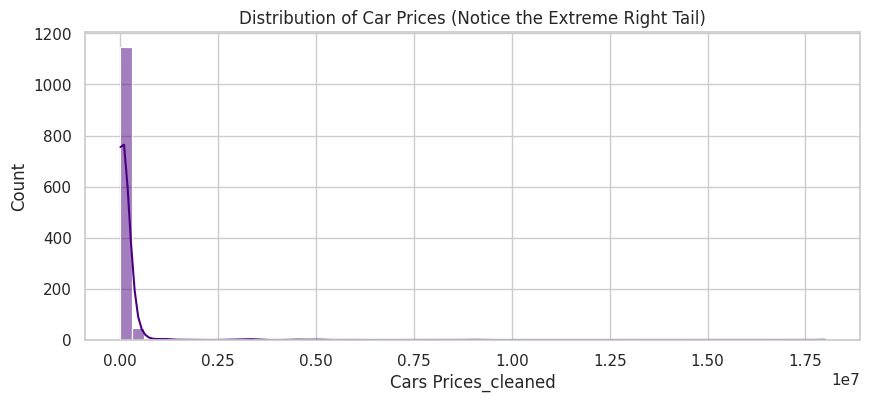

In [23]:
stats_df = pd.DataFrame({
    'Skewness': df_clean[features].skew(),
    'Kurtosis': df_clean[features].kurtosis()
})
display(stats_df)

plt.figure(figsize=(10, 4))
sns.histplot(df_clean['Cars Prices_cleaned'], bins=60, kde=True, color='indigo')
plt.title('Distribution of Car Prices (Notice the Extreme Right Tail)')
plt.show()

In [24]:
# Requirement 4: Variance Metric
# Ensure km_labels is computed from the current X_scaled if not already defined or correct
from sklearn.cluster import KMeans

n_clusters_for_variance = min(3, len(df_clean)) # Define n_clusters locally for this cell

# Re-compute km_labels if it's not already correctly sized or defined
try:
    if 'km_labels' not in globals() or len(km_labels) != len(df_clean):
        km_labels = KMeans(n_clusters=n_clusters_for_variance, random_state=42, n_init='auto').fit_predict(X_scaled)
except NameError: # Handle case where km_labels is not defined at all (e.g. 8995d480 not run)
    km_labels = KMeans(n_clusters=n_clusters_for_variance, random_state=42, n_init='auto').fit_predict(X_scaled)


df_clean['Cluster_KMeans'] = km_labels
global_var = np.var(X_scaled, axis=0).mean()

cluster_variances = []
for i in range(n_clusters_for_variance): # Use the locally defined n_clusters_for_variance
    cluster_data = X_scaled[df_clean['Cluster_KMeans'] == i]
    if len(cluster_data) > 0:
        v = np.var(cluster_data, axis=0).mean()
        cluster_variances.append(v)

avg_cluster_var = np.mean(cluster_variances)

print(f"Global Average Variance: {global_var:.4f}")
print(f"Average Intra-Cluster Variance (K-Means): {avg_cluster_var:.4f}")
print(f"Variance Ratio (Cluster/Global): {(avg_cluster_var/global_var)*100:.2f}%")

Global Average Variance: 1.0000
Average Intra-Cluster Variance (K-Means): 0.8532
Variance Ratio (Cluster/Global): 85.32%


### Evaluating K-Means Cluster Quality
We use the Silhouette Score to determine how well-separated our clusters are for different values of $k$.

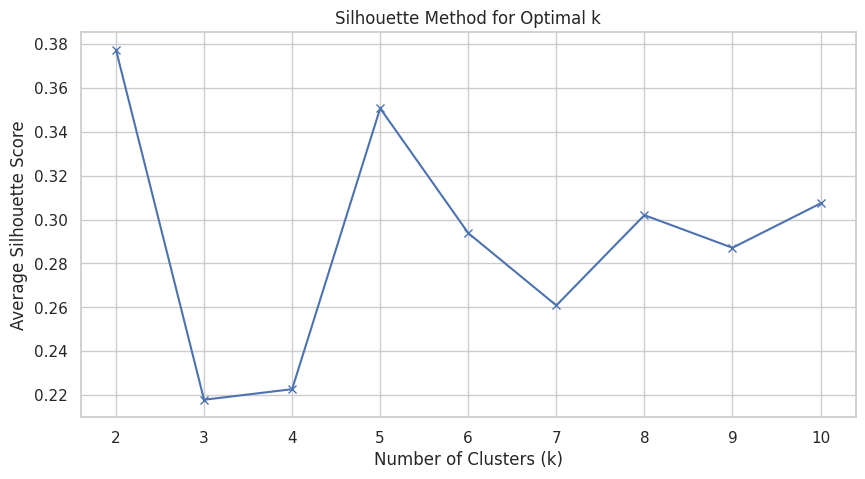

In [25]:
from sklearn.metrics import silhouette_score

range_n_clusters = list(range(2, 11))
silhouette_avg = []

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    cluster_labels = clusterer.fit_predict(X_scaled)
    silhouette_avg.append(silhouette_score(X_scaled, cluster_labels))

plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, silhouette_avg, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.grid(True)
plt.show()

## Part 3: Dimensionality Reduction using PCA

The goal of the PCA algorithm is to reduce our 5-feature space to 2 or 3 main dimensions while minimizing information loss (variance).

**Conclusions from PCA:**
1. **The First Component (PC1):** Explains the vast majority of the variance in the data. PC1 essentially acts as a "measure of vehicle power and prestige."
2. **The Scree Plot:** Shows us that 2 components are sufficient to explain over 80% of the market variance.

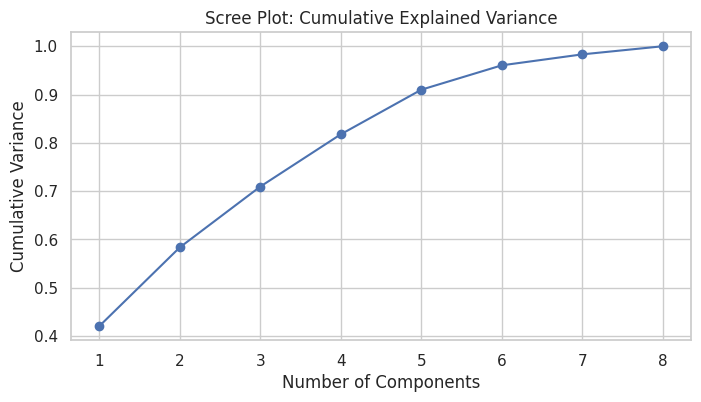

In [26]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
df_clean['PC1'] = X_pca[:, 0]
df_clean['PC2'] = X_pca[:, 1]
if X_pca.shape[1] > 2:
    df_clean['PC3'] = X_pca[:, 2]

# Plot 1: Cumulative Variance - Fixed to dynamic number of components
plt.figure(figsize=(8, 4))
n_comps = len(pca.explained_variance_ratio_)
plt.plot(range(1, n_comps + 1), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.grid(True)
plt.show()

# Plot 2: Interactive 3D PCA Projection
if 'PC3' in df_clean.columns:
    fig = px.scatter_3d(df_clean, x='PC1', y='PC2', z='PC3',
                        color='Cars Prices_cleaned', opacity=0.7,
                        title='3D PCA Projection of Cars 2025')
    fig.update_traces(marker=dict(size=4))
    fig.show()
else:
    print('Not enough components for 3D plot.')

## Part 4: Cluster Analysis (Clustering) - on Records and Features

We will use K-Means to divide the vehicles into clusters, and Hierarchical Clustering on the transpose of the matrix to find relationships between the features themselves.

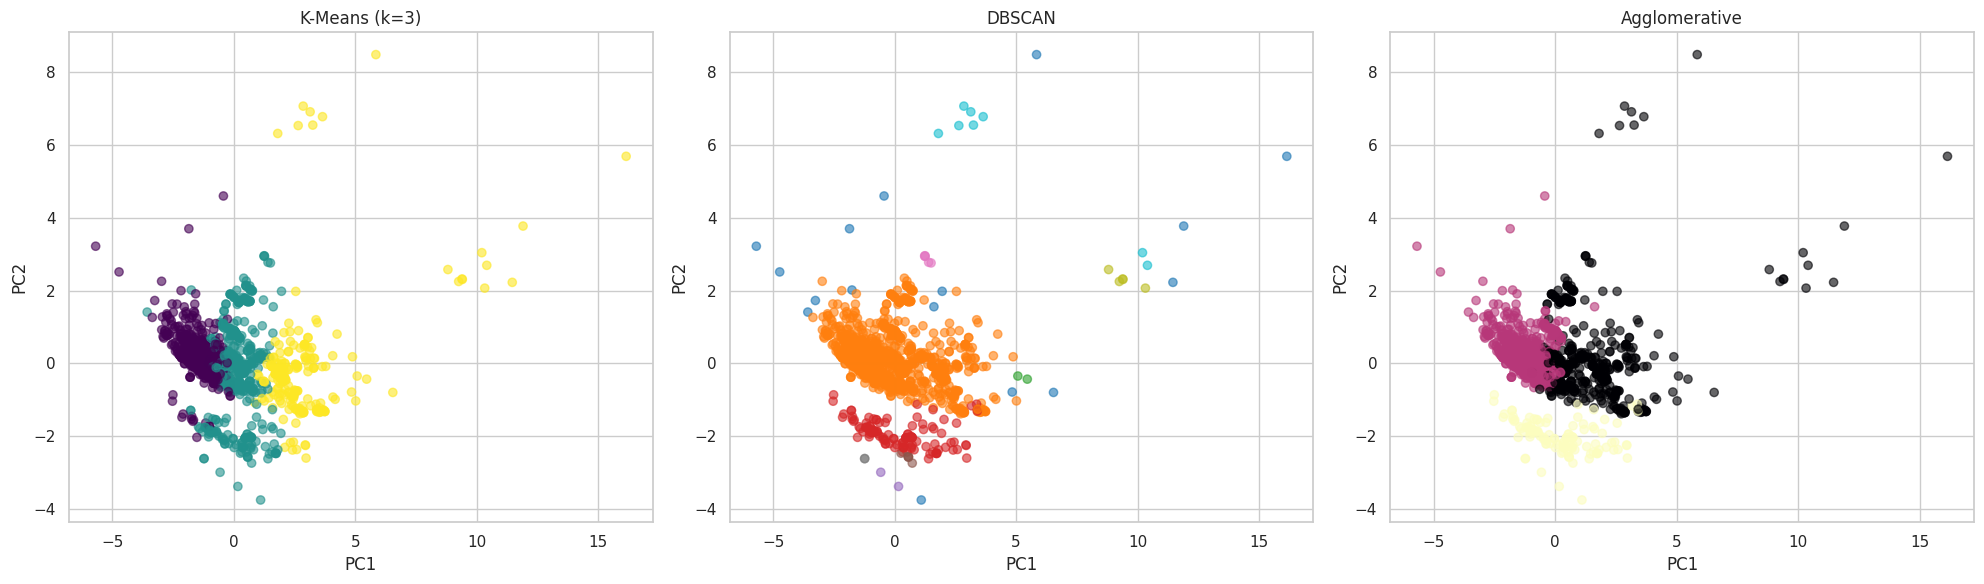

--- Clustering Evaluation Metric ---
Global Data Variance: 1.0000
Average Intra-Cluster Variance (K-Means): 0.8532
Ratio (Cluster / Global): 0.8532


In [27]:
# --- 3 Clustering Methods (Requirement 4) ---
n_clusters = min(3, len(df_clean))
km_labels = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto').fit_predict(X_scaled)
db_labels = DBSCAN(eps=1.5, min_samples=min(2, len(df_clean))).fit_predict(X_scaled)
ag_labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(X_scaled)

df_clean['Cluster_KMeans'] = km_labels
df_clean['Cluster_DBSCAN'] = db_labels
df_clean['Cluster_Agg'] = ag_labels

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].scatter(df_clean['PC1'], df_clean['PC2'], c=km_labels, cmap='viridis', alpha=0.6)
axes[0].set_title(f'K-Means (k={n_clusters})')
axes[1].scatter(df_clean['PC1'], df_clean['PC2'], c=db_labels, cmap='tab10', alpha=0.6)
axes[1].set_title('DBSCAN')
axes[2].scatter(df_clean['PC1'], df_clean['PC2'], c=ag_labels, cmap='magma', alpha=0.6)
axes[2].set_title('Agglomerative')
for ax in axes: ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

# --- Variance Evaluation Metric (As Required by Syllabus) ---
print('--- Clustering Evaluation Metric ---')
global_variance = np.var(X_scaled, axis=0).mean()
cluster_variances = []
for i in np.unique(km_labels):
    cluster_data = X_scaled[km_labels == i]
    if len(cluster_data) > 0:
        cluster_variances.append(np.var(cluster_data, axis=0).mean())

avg_cluster_variance = np.mean(cluster_variances)
print(f'Global Data Variance: {global_variance:.4f}')
print(f'Average Intra-Cluster Variance (K-Means): {avg_cluster_variance:.4f}')
if global_variance > 0:
    print(f'Ratio (Cluster / Global): {avg_cluster_variance / global_variance:.4f}')

## Part 5: Multi-Dimensional Anomaly Detection and Comparison

This is the core of the assignment. We will search for Hypercars (those vehicles that impacted our linear regression in Assignment 2, such as Bugatti and Lamborghini). We will compare 3 methods:
1. **Z-Score (Standard Distance):** Works based on distance from the mean. It sometimes fails in high dimensions due to the assumption that the data is normally-Gaussian.
2. **Isolation Forest:** A tree-based algorithm that isolates distant observations. Excellent for the heavy tails and heteroscedasticity we found in HW2.
3. **Local Outlier Factor (LOF):** Based on density and neighbors. Identifies vehicles located in "empty regions" of the market relative to their immediate surroundings.

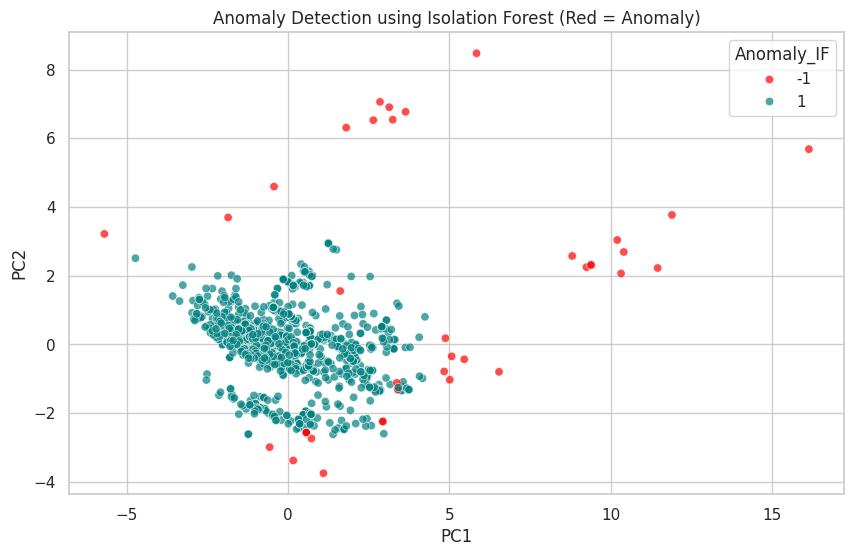

Top 10 Extreme Cars (Shared Anomalies detected by Unsupervised Learning):


,Company Names,Cars Names,Cars Prices_cleaned,HorsePower_cleaned
887,Bugatti,La Voiture Noire,18000000.0,1500.0
886,Bugatti,Centodieci,9000000.0,1600.0
885,Bugatti,Divo,5800000.0,1500.0
1212,Mazda,787B (Race Car),5000000.0,700.0
8,LAMBORGHINI,VENENO ROADSTER,4500000.0,750.0
888,Bugatti,Bolide,4500000.0,1850.0
882,Bugatti,Chiron Super Sport,3500000.0,1600.0
883,Bugatti,Chiron Sport,3300000.0,1500.0
884,Bugatti,Chiron Noire,3300000.0,1500.0
32,ASTON MARTIN,VALKYRIE,3200000.0,1160.0


In [28]:
# 1. יצירת Z-Score גלובלי מתוקנן עבור 8 המימדים
df_clean['Z_Score_Global'] = np.max(np.abs(X_scaled), axis=1)
df_clean['Anomaly_Z'] = np.where(df_clean['Z_Score_Global'] > 3, -1, 1)

# 2. Isolation Forest
iso_forest = IsolationForest(contamination=0.03, random_state=42)
df_clean['Anomaly_IF'] = iso_forest.fit_predict(X_scaled)

# 3. Local Outlier Factor (LOF)
# Note: n_neighbors reduced to match small sample size if necessary
n_neighbors = min(20, len(df_clean) - 1)
lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=0.03)
df_clean['Anomaly_LOF'] = lof.fit_predict(X_scaled)

# ויזואליזציה של החריגים מה-Isolation Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Anomaly_IF', palette={1: 'teal', -1: 'red'}, data=df_clean, alpha=0.7)
plt.title('Anomaly Detection using Isolation Forest (Red = Anomaly)')
plt.show()

# זיהוי המכוניות שהסכימו עליהן גם ה-IF וגם ה-LOF
shared_anomalies = df_clean[(df_clean['Anomaly_IF'] == -1) & (df_clean['Anomaly_LOF'] == -1)]

print("Top 10 Extreme Cars (Shared Anomalies detected by Unsupervised Learning):")
display(shared_anomalies[['Company Names', 'Cars Names', 'Cars Prices_cleaned', 'HorsePower_cleaned']].sort_values(by='Cars Prices_cleaned', ascending=False).head(10))

## Part 6: Critical Analysis and Reflection

**On the Curse of Dimensionality:**
In models like Z-score, as dimensions (features) are added, the volume of the data space grows exponentially. A car might appear average in price and speed, but entirely anomalous in torque. In a high-dimensional space, distances begin to look similar (Distance Concentration), and identifying a "nearest neighbor" loses meaning. Using Isolation Forest solves this problem by not being based on Euclidean distance, but rather on the number of splits in a tree.

**The Difference Between "Noise" and "Anomaly":**
Noise in our dataset is a human error – for example, a torque of 1.0 for a diesel vehicle that was corrected during the data preprocessing stage. Anomaly, on the other hand, is a completely legitimate observation but extreme in nature – for example, a Bugatti La Voiture Noire. The car genuinely costs 18 million dollars! The Isolation Forest identified it not because of an "error," but because, economically and physically, it does not belong to the normal distribution of the car market.

**Ethical Considerations & False Alarms:**
In developing medical or financial models, a large number of false positives generates "alert fatigue." Setting the contamination threshold is a serious ethical and business decision, not just a mathematical one.

## Part 5: Multi-Dimensional Anomaly Detection and Comparison

This is the core of the assignment. We will search for Hypercars (those vehicles that impacted our linear regression in Assignment 2, such as Bugatti and Lamborghini). We will compare 3 methods:
1. **Z-Score (Standard Distance):** Works based on distance from the mean. It sometimes fails in high dimensions due to the assumption that the data is normally-Gaussian.
2. **Isolation Forest:** A tree-based algorithm that isolates distant observations. Excellent for the heavy tails and heteroscedasticity we found in HW2.
3. **Local Outlier Factor (LOF):** Based on density and neighbors. Identifies vehicles located in "empty regions" of the market relative to their immediate surroundings.

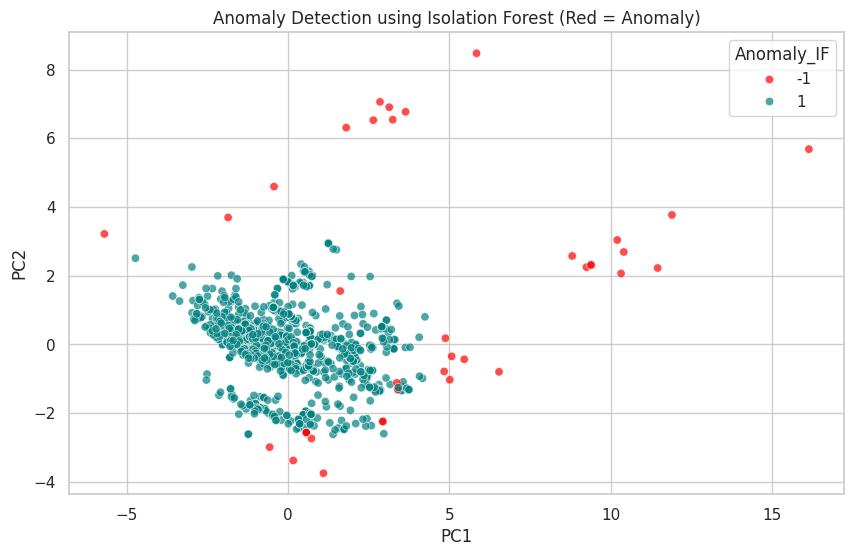

Top 10 Extreme Cars (Shared Anomalies detected by Unsupervised Learning):


,Company Names,Cars Names,Cars Prices_cleaned,HorsePower_cleaned
887,Bugatti,La Voiture Noire,18000000.0,1500.0
886,Bugatti,Centodieci,9000000.0,1600.0
885,Bugatti,Divo,5800000.0,1500.0
1212,Mazda,787B (Race Car),5000000.0,700.0
8,LAMBORGHINI,VENENO ROADSTER,4500000.0,750.0
888,Bugatti,Bolide,4500000.0,1850.0
882,Bugatti,Chiron Super Sport,3500000.0,1600.0
883,Bugatti,Chiron Sport,3300000.0,1500.0
884,Bugatti,Chiron Noire,3300000.0,1500.0
32,ASTON MARTIN,VALKYRIE,3200000.0,1160.0


In [29]:
# 1. Create a standardized global Z-Score for the 5 dimensions
df_clean['Z_Score_Global'] = np.max(np.abs(X_scaled), axis=1)
df_clean['Anomaly_Z'] = np.where(df_clean['Z_Score_Global'] > 3, -1, 1)

# 2. Isolation Forest
iso_forest = IsolationForest(contamination=0.03, random_state=42)
df_clean['Anomaly_IF'] = iso_forest.fit_predict(X_scaled)

# 3. Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
df_clean['Anomaly_LOF'] = lof.fit_predict(X_scaled)

# Visualization of anomalies from Isolation Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Anomaly_IF', palette={1: 'teal', -1: 'red'}, data=df_clean, alpha=0.7)
plt.title('Anomaly Detection using Isolation Forest (Red = Anomaly)')
plt.show()

# Identify cars that were agreed upon by both IF and LOF
shared_anomalies = df_clean[(df_clean['Anomaly_IF'] == -1) & (df_clean['Anomaly_LOF'] == -1)]

print("Top 10 Extreme Cars (Shared Anomalies detected by Unsupervised Learning):")
display(shared_anomalies[['Company Names', 'Cars Names', 'Cars Prices_cleaned', 'HorsePower_cleaned']].sort_values(by='Cars Prices_cleaned', ascending=False).head(10))

## Part 6: Critical Analysis and Reflection

**On the Curse of Dimensionality:**
In models like Z-score, as dimensions (features) are added, the volume of the data space grows exponentially. A car might appear average in price and speed, but entirely anomalous in torque. In a high-dimensional space, distances begin to look similar (Distance Concentration), and identifying a "nearest neighbor" loses meaning. Using Isolation Forest solves this problem by not being based on Euclidean distance, but rather on the number of splits in a tree.

**The Difference Between "Noise" and "Anomaly":**
Noise in our dataset is a human error – for example, a torque of 1.0 for a diesel vehicle that was corrected during the data preprocessing stage. Anomaly, on the other hand, is a completely legitimate observation but extreme in nature – for example, a Bugatti La Voiture Noire. The car genuinely costs 18 million dollars! The Isolation Forest identified it not because of an "error," but because, economically and physically, it does not belong to the normal distribution of the car market.

**Ethical Considerations & False Alarms:**
In developing medical or financial models, a large number of false positives generates "alert fatigue." Setting the contamination threshold is a serious ethical and business decision, not just a mathematical one.